# UMAP de Newsgroups20 sobre el subconjunto de 8 categorias

Este notebook visualiza el subset generado a partir de 20 Newsgroups para estudiar si las 8 categorias tecnicas seleccionadas forman una masa semantica suficientemente coherente para topic modeling.

Objetivos:
- Cargar el subset exportado en el EDA.
- Explorar longitud y distribucion por categorias.
- Proyectar el subset con UMAP usando BoW, TF-IDF, Nomic y Qwen3 embeddings.
- Visualizar la separacion entre categorias y guardar artefactos reproducibles.

In [1]:
from __future__ import annotations

import importlib.util
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_colwidth", 160)

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Resolver el root del repositorio y preparar rutas de salida
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (
            p
            for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents]
            if (
                p
                / "validation"
                / "results"
                / "newsgroups20_eda"
                / "tables"
                / "newsgroups20_topic8_subset.csv"
            ).exists()
        ),
        CANDIDATE_ROOT,
    )

EDA_TABLES = ROOT / "validation" / "results" / "newsgroups20_eda" / "tables"
UMAP_DIR = ROOT / "validation" / "results" / "newsgroups20_umap"
TABLES_DIR = UMAP_DIR / "tables"
FIGURES_DIR = UMAP_DIR / "figures"
CACHE_DIR = UMAP_DIR / "cache"
for p in [UMAP_DIR, TABLES_DIR, FIGURES_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Cargar helpers locales para embeddings en Ollama
ollama_module_path = ROOT / "validation" / "representation" / "ollama_embeddings.py"
ollama_spec = importlib.util.spec_from_file_location(
    "validation.representation.ollama_embeddings",
    ollama_module_path,
 )
if ollama_spec is None or ollama_spec.loader is None:
    raise ImportError(f"No se pudo cargar el modulo de embeddings: {ollama_module_path}")
ollama_module = importlib.util.module_from_spec(ollama_spec)
ollama_spec.loader.exec_module(ollama_module)
OllamaEmbeddings = ollama_module.OllamaEmbeddings

# Cargar embedder optimizado (async + GPU)
ollama_opt_path = ROOT / "validation" / "representation" / "ollama_embeddings_optimized.py"
ollama_opt_spec = importlib.util.spec_from_file_location(
    "validation.representation.ollama_embeddings_optimized",
    ollama_opt_path,
)
if ollama_opt_spec is None or ollama_opt_spec.loader is None:
    print(f"⚠️  No optimized embedder found at {ollama_opt_path}")
    OllamaEmbeddingsOptimized = OllamaEmbeddings
else:
    ollama_opt_module = importlib.util.module_from_spec(ollama_opt_spec)
    ollama_opt_spec.loader.exec_module(ollama_opt_module)
    OllamaEmbeddingsOptimized = ollama_opt_module.OllamaEmbeddingsOptimized
    print(f"✅ Loaded optimized embedder: {ollama_opt_path}")

print(f"ROOT: {ROOT}")
print(f"Subset source: {EDA_TABLES / 'newsgroups20_topic8_subset.csv'}")
print(f"Output dir: {UMAP_DIR}")
print(f"Cache dir: {CACHE_DIR}")

✅ Loaded optimized embedder: /home/gabriel/clase/TFG/TFG-Chatbot/validation/representation/ollama_embeddings_optimized.py
ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Subset source: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv
Output dir: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_umap
Cache dir: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_umap/cache


In [3]:
# Cargar el subset de 8 categorias
subset_path = EDA_TABLES / "newsgroups20_topic8_subset.csv"
subset_counts_path = EDA_TABLES / "newsgroups20_topic8_subset_label_distribution.csv"

df = pd.read_csv(subset_path)
if "text" not in df.columns:
    if "document" in df.columns:
        df = df.rename(columns={"document": "text"})
    else:
        raise ValueError("El subset no contiene columna 'text' ni 'document'.")

if subset_counts_path.exists():
    selected_labels = pd.read_csv(subset_counts_path)["label"].tolist()
else:
    selected_labels = sorted(df["label"].astype(str).unique().tolist())

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str)
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)
if "char_len" not in df.columns:
    df["char_len"] = df["text"].str.len()
if "tok_len" not in df.columns:
    df["tok_len"] = df["text"].str.findall(r"\w+").str.len()

print(f"Filas del subset: {len(df)}")
print(f"Labels unicas: {df['label'].nunique()}")
print(f"Labels seleccionados: {selected_labels}")
display(df.head())

Filas del subset: 7614
Labels unicas: 8
Labels seleccionados: ['comp.windows.x', 'sci.crypt', 'comp.sys.ibm.pc.hardware', 'sci.electronics', 'sci.space', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.mac.hardware']


,text,label_id,label,char_len,tok_len
0,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief message detailing\nyou...,4,comp.sys.mac.hardware,530,92
1,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as a 512k way back in 1985. sooo, i'm in the market for a\nnew machine ...",4,comp.sys.mac.hardware,1659,310
2,Do you have Weitek's address/phone number? I'd like to get some information\nabout this chip.,1,comp.graphics,93,18
3,"From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):\n\n\nMy understanding is that the 'expected errors' are basically\nknown b...",14,sci.space,448,80
4,ALL this shows is that YOU don't know much about SCSI.\n\nSCSI-1 {with a SCSI-1 controler chip} range is indeed 0-5MB/s\nand that is ALL you have right abou...,3,comp.sys.ibm.pc.hardware,1525,322


In [4]:
# Resumen descriptivo del subset
subset_summary = {
    "n_rows": len(df),
    "n_labels": int(df["label"].nunique()),
    "char_len_mean": float(df["char_len"].mean()),
    "char_len_median": float(df["char_len"].median()),
    "tok_len_mean": float(df["tok_len"].mean()),
    "tok_len_median": float(df["tok_len"].median()),
}
subset_summary_df = pd.DataFrame([subset_summary])
subset_summary_df.to_csv(TABLES_DIR / "newsgroups20_subset_summary.csv", index=False, encoding="utf-8")
display(subset_summary_df)

label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.to_csv(TABLES_DIR / "newsgroups20_subset_label_counts.csv", index=False, encoding="utf-8")
display(label_counts)

,n_rows,n_labels,char_len_mean,char_len_median,tok_len_mean,tok_len_median
0,7614,8,1196.85658,471.0,212.687549,83.0


,label,count
0,comp.windows.x,963
1,sci.crypt,962
2,comp.sys.ibm.pc.hardware,959
3,sci.electronics,955
4,sci.space,953
5,comp.graphics,951
6,comp.os.ms-windows.misc,943
7,comp.sys.mac.hardware,928


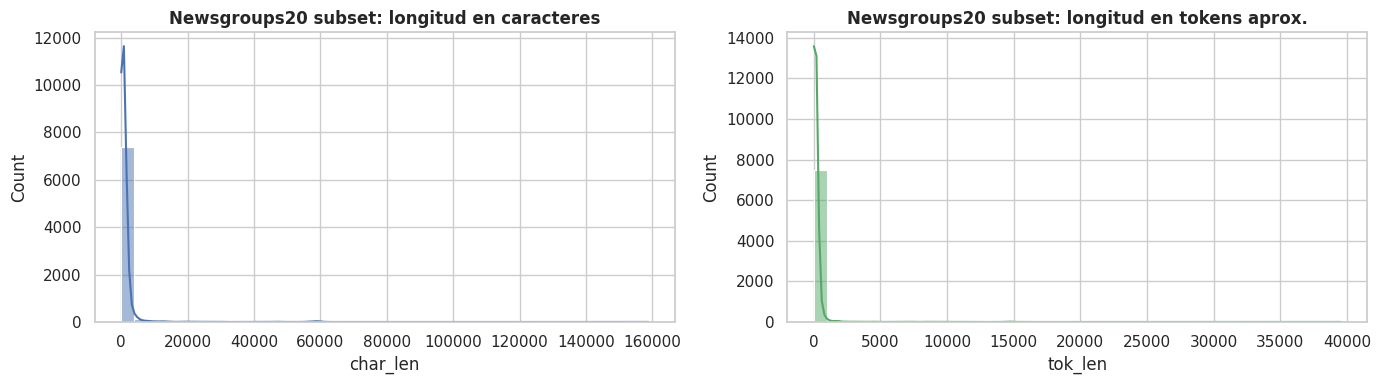

In [5]:
# Distribuciones basicas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["char_len"], bins=40, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Newsgroups20 subset: longitud en caracteres")
axes[0].set_xlabel("char_len")

sns.histplot(df["tok_len"], bins=40, kde=True, ax=axes[1], color="#55a868")
axes[1].set_title("Newsgroups20 subset: longitud en tokens aprox.")
axes[1].set_xlabel("tok_len")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "newsgroups20_subset_length_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

In [6]:
# Frecuencias lexicales
texts = df["text"].tolist()

cv_uni = CountVectorizer(stop_words="english", ngram_range=(1, 1), min_df=3, max_df=0.9)
X_uni = cv_uni.fit_transform(texts)
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()
top_uni_idx = np.argsort(freq_uni)[::-1][:25]
df_top_uni = pd.DataFrame({
    "term": np.array(cv_uni.get_feature_names_out())[top_uni_idx],
    "count": freq_uni[top_uni_idx],
})

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=3, max_df=0.9)
X_bi = cv_bi.fit_transform(texts)
freq_bi = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi_idx = np.argsort(freq_bi)[::-1][:25]
df_top_bi = pd.DataFrame({
    "term": np.array(cv_bi.get_feature_names_out())[top_bi_idx],
    "count": freq_bi[top_bi_idx],
})

df_top_uni.to_csv(TABLES_DIR / "newsgroups20_subset_top_unigrams.csv", index=False, encoding="utf-8")
df_top_bi.to_csv(TABLES_DIR / "newsgroups20_subset_top_bigrams.csv", index=False, encoding="utf-8")
display(df_top_uni.head(10))
display(df_top_bi.head(10))

,term,count
0,ax,62396
1,max,4593
2,use,3398
3,like,2632
4,file,2230
5,just,2226
6,edu,2199
7,know,2191
8,don,2111
9,windows,2106


,term,count
0,ax ax,56325
1,max ax,4334
2,ax max,4315
3,g9v g9v,824
4,a86 a86,639
5,b8f b8f,593
6,145 145,428
7,dos dos,411
8,don know,356
9,thanks advance,348


In [7]:
# Representaciones vectoriales
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, max_df=0.95)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True)

X_bow = bow_vectorizer.fit_transform(texts)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

import time

ollama_host = os.getenv("OLLAMA_HOST", "localhost")
ollama_port = int(os.getenv("OLLAMA_PORT", "11434"))

# OPTIMIZED SETTINGS (GPU + async) con limites mas robustos para evitar overflows de contexto.
print("=" * 70)
print("INITIALIZING OPTIMIZED EMBEDDERS (GPU + ASYNC)")
print("=" * 70)

nomic_embedder = OllamaEmbeddingsOptimized(
    model="nomic-embed-text",
    host=ollama_host,
    port=ollama_port,
    max_input_tokens=256,
    max_input_chars=8000,
    max_concurrent_requests=6,
    max_retries=2,
    max_failed_ratio=0.01,
)

qwen_embedder = OllamaEmbeddingsOptimized(
    model="qwen3-embedding:0.6b",
    host=ollama_host,
    port=ollama_port,
    max_input_tokens=256,
    max_input_chars=8000,
    max_concurrent_requests=6,
    max_retries=2,
    max_failed_ratio=0.01,
)

print(
    f"Nomic embedder: {ollama_host}:{ollama_port} "
    f"(concurrent={nomic_embedder.max_concurrent_requests}, "
    f"max_tokens={nomic_embedder.max_input_tokens}, max_chars={nomic_embedder.max_input_chars})"
)
print(
    f"Qwen3 embedder: {ollama_host}:{ollama_port} "
    f"(concurrent={qwen_embedder.max_concurrent_requests}, "
    f"max_tokens={qwen_embedder.max_input_tokens}, max_chars={qwen_embedder.max_input_chars})"
)
print("=" * 70)

nomic_cache = CACHE_DIR / f"nomic_embeddings_n{len(texts)}.npy"
qwen_cache = CACHE_DIR / f"qwen3_embeddings_n{len(texts)}.npy"

def load_or_create_embeddings(
    cache_path: Path,
    embedder: OllamaEmbeddingsOptimized,
    texts: list[str],
    name: str,
    use_async: bool = True,
) -> np.ndarray:
    """Load or create embeddings with optimized async batching.

    Args:
        cache_path: Path to cache file
        embedder: OllamaEmbeddingsOptimized instance
        texts: List of texts to embed
        name: Name for logging
        use_async: Use async backend (faster on large batches)

    Returns:
        Embedding matrix of shape (n_texts, 768)
    """
    if cache_path.exists():
        X = np.load(cache_path)
        print(f"Loaded cached {name} embeddings from {cache_path} -> shape {X.shape}")
        return X

    print(f"Generating {name} embeddings (async={use_async})...")
    print(f"   Input: {len(texts)} texts, Max concurrent requests: {embedder.max_concurrent_requests}")

    start_time = time.time()

    try:
        X = embedder.embed_batch(texts, normalize=True, use_async=use_async).astype(np.float32)

        elapsed = time.time() - start_time
        tokens_per_sec = sum(len(t.split()) for t in texts) / max(elapsed, 1e-9)

        print(f"Generated {name} embeddings in {elapsed:.1f}s ({tokens_per_sec:.0f} tok/s)")
        print(f"   Shape: {X.shape}")

        np.save(cache_path, X)
        print(f"Cached to {cache_path}")

        return X

    except Exception as exc:
        raise RuntimeError(
            f"Failed to generate {name} embeddings. "
            f"Check Ollama at {embedder.base_url} and verify model availability.",
        ) from exc

print()
X_nomic = load_or_create_embeddings(nomic_cache, nomic_embedder, texts, "Nomic", use_async=True)
print()
X_qwen = load_or_create_embeddings(qwen_cache, qwen_embedder, texts, "Qwen3", use_async=True)
print()

def matrix_stats(name: str, X) -> dict:
    n, d = X.shape
    nnz = int(X.nnz) if hasattr(X, "nnz") else int(np.count_nonzero(X))
    return {
        "representation": name,
        "n_samples": int(n),
        "n_features": int(d),
        "nnz": nnz,
        "sparsity": float(1.0 - (nnz / (n * d))),
        "avg_nnz_per_doc": float(nnz / n),
    }

repr_stats = pd.DataFrame(
    [
        matrix_stats("bow", X_bow),
        matrix_stats("tfidf", X_tfidf),
        matrix_stats("nomic", X_nomic),
        matrix_stats("qwen3", X_qwen),
    ]
)
repr_stats.to_csv(TABLES_DIR / "newsgroups20_subset_representation_stats.csv", index=False, encoding="utf-8")
display(repr_stats)

print("=" * 70)
print("EMBEDDING GENERATION COMPLETE")
print("=" * 70)

INITIALIZING OPTIMIZED EMBEDDERS (GPU + ASYNC)
Nomic embedder: localhost:11434 (concurrent=6, max_tokens=256, max_chars=8000)
Qwen3 embedder: localhost:11434 (concurrent=6, max_tokens=256, max_chars=8000)

Generating Nomic embeddings (async=True)...
   Input: 7614 texts, Max concurrent requests: 6
Generated Nomic embeddings in 72.8s (17766 tok/s)
   Shape: (7614, 768)
Cached to /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_umap/cache/nomic_embeddings_n7614.npy

Generating Qwen3 embeddings (async=True)...
   Input: 7614 texts, Max concurrent requests: 6
Generated Qwen3 embeddings in 463.2s (2792 tok/s)
   Shape: (7614, 1024)
Cached to /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/newsgroups20_umap/cache/qwen3_embeddings_n7614.npy



,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,7614,5000,695759,0.981724,91.378907
1,tfidf,7614,5000,695759,0.981724,91.378907
2,nomic,7614,768,5847552,0.000000,768.000000
3,qwen3,7614,1024,7796736,0.000000,1024.000000


EMBEDDING GENERATION COMPLETE


In [8]:
# UMAP sobre las cuatro representaciones
umap_kwargs = {
    "n_components": 2,
    "n_neighbors": 15,
    "min_dist": 0.12,
    "metric": "cosine",
    "random_state": 42,
}

def project_representation(name: str, matrix) -> pd.DataFrame:
    reducer = UMAP(**umap_kwargs)
    coords = reducer.fit_transform(matrix)
    out = df[["text", "label", "char_len", "tok_len"]].copy()
    out["representation"] = name
    out["umap_1"] = coords[:, 0]
    out["umap_2"] = coords[:, 1]
    out.to_csv(TABLES_DIR / f"newsgroups20_subset_{name}_umap.csv", index=False, encoding="utf-8")
    return out

proj_bow = project_representation("bow", X_bow)
proj_tfidf = project_representation("tfidf", X_tfidf)
proj_nomic = project_representation("nomic", X_nomic)
proj_qwen = project_representation("qwen3", X_qwen)

display(proj_bow.head())

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,text,label,char_len,tok_len,representation,umap_1,umap_2
0,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their experiences for this poll. Please send a brief message detailing\nyou...,comp.sys.mac.hardware,530,92,bow,13.381709,16.742359
1,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as a 512k way back in 1985. sooo, i'm in the market for a\nnew machine ...",comp.sys.mac.hardware,1659,310,bow,13.935899,18.112713
2,Do you have Weitek's address/phone number? I'd like to get some information\nabout this chip.,comp.graphics,93,18,bow,10.652045,20.506321
3,"From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):\n\n\nMy understanding is that the 'expected errors' are basically\nknown b...",sci.space,448,80,bow,13.607860,17.765490
4,ALL this shows is that YOU don't know much about SCSI.\n\nSCSI-1 {with a SCSI-1 controler chip} range is indeed 0-5MB/s\nand that is ALL you have right abou...,comp.sys.ibm.pc.hardware,1525,322,bow,13.259459,20.605341


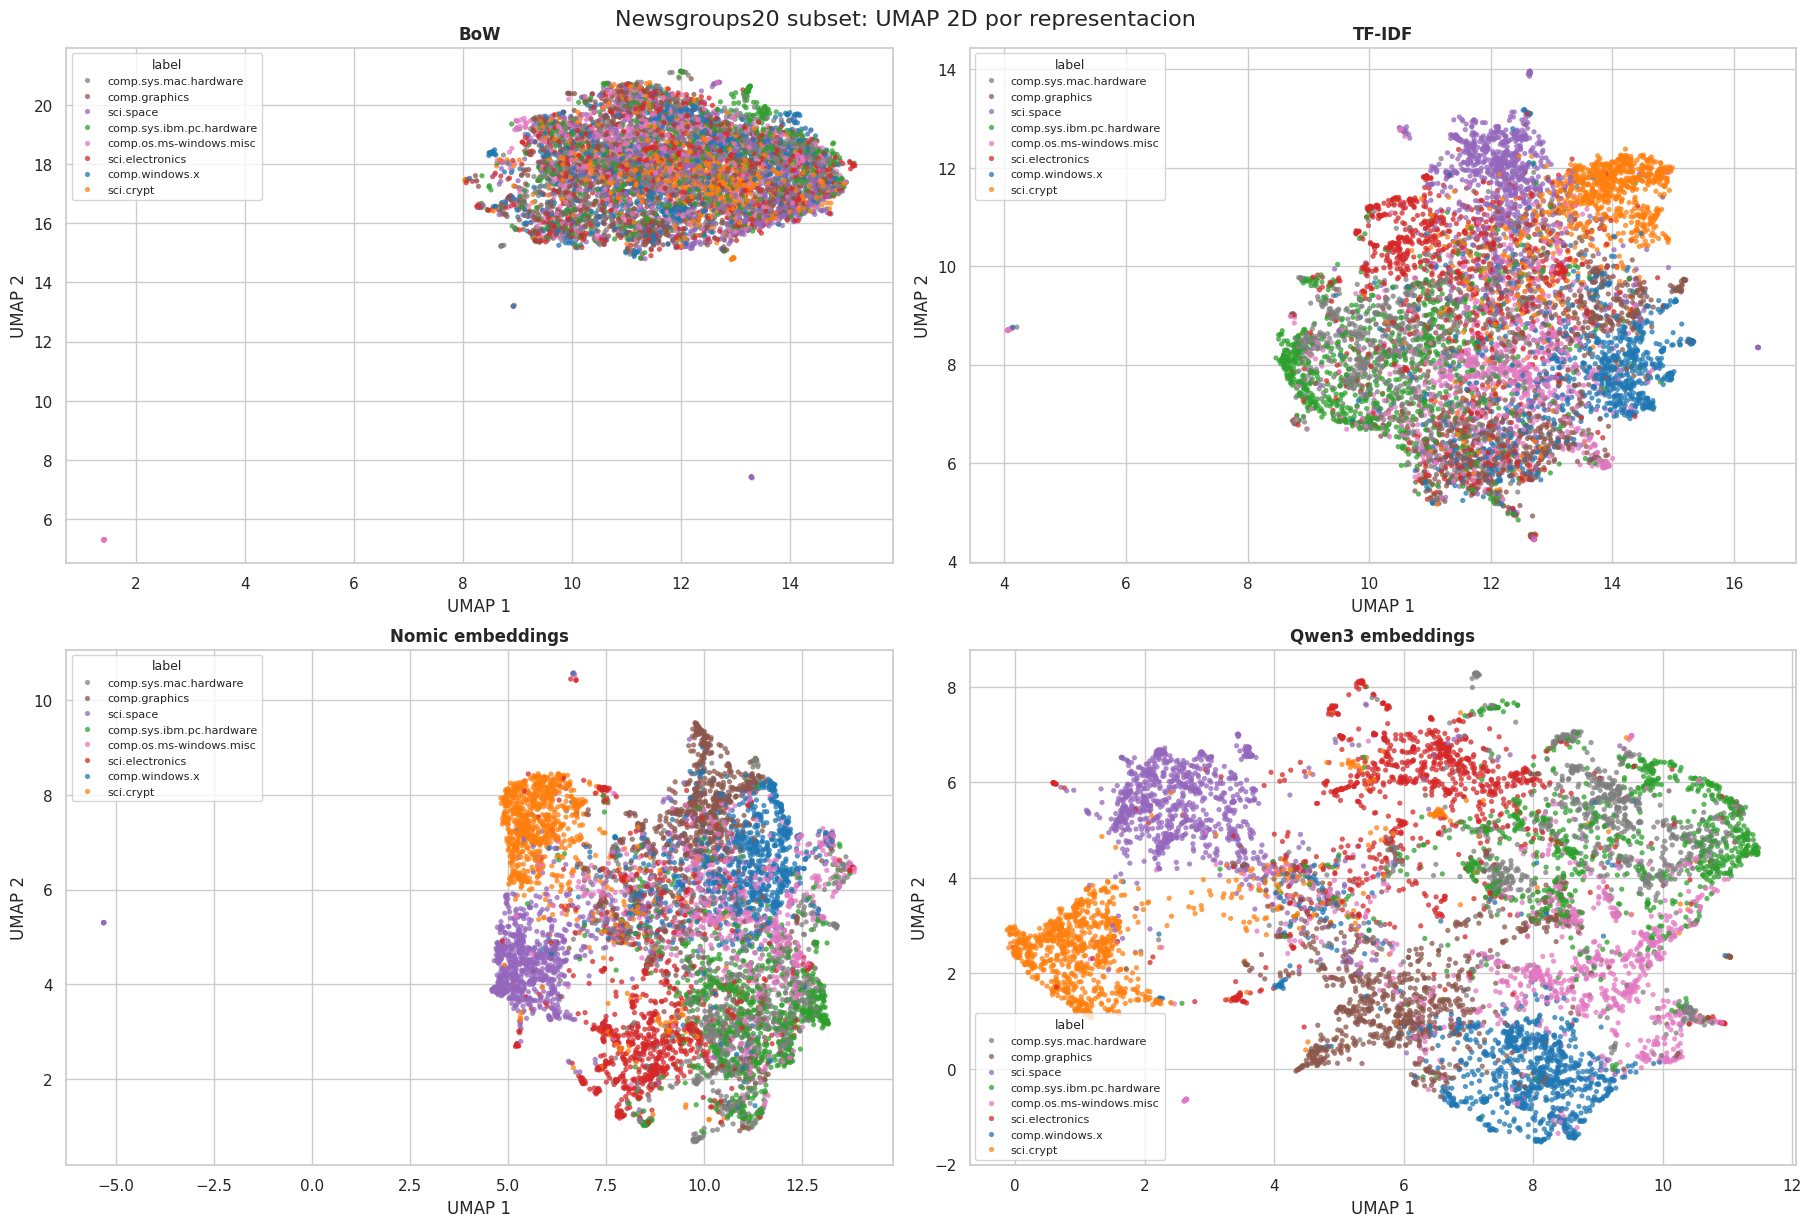

In [9]:
# Visualizacion comparativa de UMAP
palette = dict(zip(selected_labels, sns.color_palette("tab10", n_colors=len(selected_labels)).as_hex()))
plots = [
    (proj_bow, "BoW"),
    (proj_tfidf, "TF-IDF"),
    (proj_nomic, "Nomic embeddings"),
    (proj_qwen, "Qwen3 embeddings"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
for ax, (proj, title) in zip(axes.flat, plots):
    sns.scatterplot(
        data=proj,
        x="umap_1",
        y="umap_2",
        hue="label",
        palette=palette,
        s=14,
        alpha=0.75,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="label", fontsize=8, title_fontsize=9, loc="best")

fig.suptitle("Newsgroups20 subset: UMAP 2D por representacion", fontsize=16, y=1.01)
fig.savefig(FIGURES_DIR / "newsgroups20_subset_umap_four_representations.png", dpi=180, bbox_inches="tight")
plt.show()

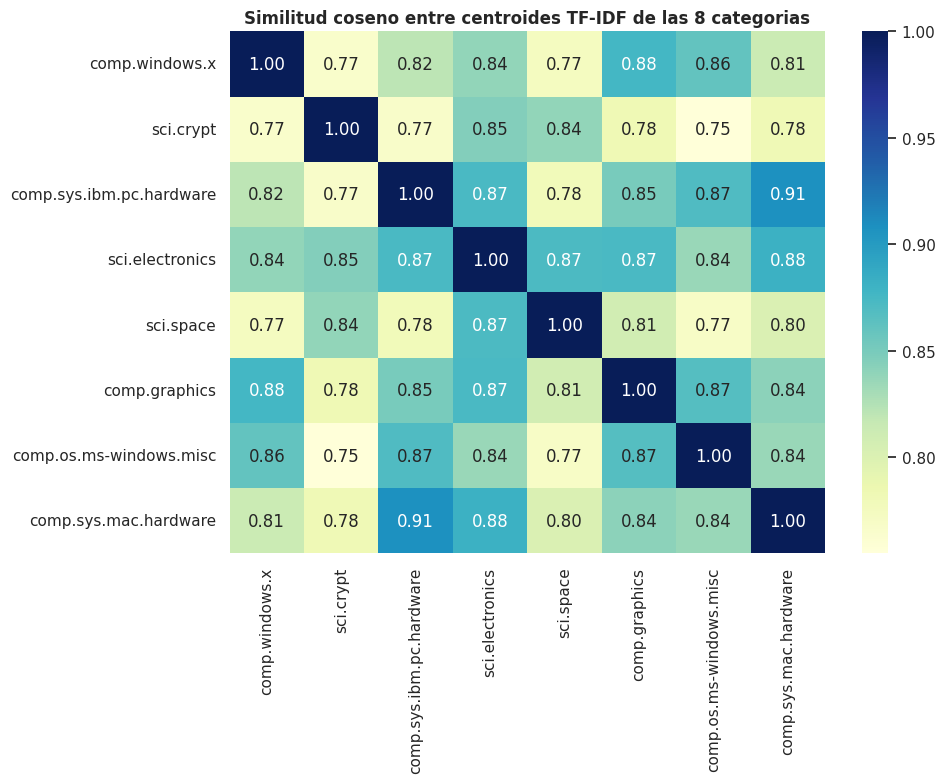

In [10]:
# Heatmap de centroides TF-IDF por categoria
label_centroids = []
for label in selected_labels:
    rows = np.where(df["label"].values == label)[0]
    centroid = np.asarray(X_tfidf[rows].mean(axis=0)).ravel()
    label_centroids.append(centroid)

centroids = np.vstack(label_centroids)
similarity = cosine_similarity(centroids)
sim_df = pd.DataFrame(similarity, index=selected_labels, columns=selected_labels)
sim_df.to_csv(TABLES_DIR / "newsgroups20_subset_centroid_cosine_similarity.csv", encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Similitud coseno entre centroides TF-IDF de las 8 categorias")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "newsgroups20_subset_centroid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## Resultado principal

Este notebook deja listo el subset de Newsgroups20 para experimentacion de topic modeling y guarda las visualizaciones en validation/results/newsgroups20_umap/.

Las figuras mas relevantes son:
- newsgroups20_subset_umap_four_representations.png
- newsgroups20_subset_centroid_similarity.png